# 02 — Revenue Forecasting
**Financial Operations Analytics**

We reconstruct a **monthly recurring revenue (MRR)** time series from the customer
panel, decompose it into trend / seasonality / residual, then benchmark three
classical and modern forecasters — **SARIMA**, **Prophet**, and **Holt-Winters
(triple exponential smoothing)** — on a 12-month hold-out. The winning model
produces a **12-month forward forecast** with confidence intervals, consumed by the
dashboard (NB 05).

Models are scored with **MAE, RMSE and MAPE**.


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "dashboard"} else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.viz import set_style, save_fig
from src.metrics import forecast_scores, scores_table
set_style()

PROC = ROOT / "data" / "processed" / "telco_clean.csv"
SERIES_OUT = ROOT / "data" / "processed" / "monthly_revenue.csv"
FORECAST_OUT = ROOT / "data" / "processed" / "revenue_forecast.csv"
REFERENCE = pd.Timestamp("2021-02-01")

# Optional dependency: Prophet may be unavailable on some installs.
try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception as e:        # pragma: no cover
    HAS_PROPHET = False
    print("Prophet unavailable -> SARIMA + Holt-Winters only:", e)

## 1. Build the monthly revenue (MRR) series
Each customer contributes their `Monthly Charges` for every month they were active —
from `SignupMonth` through `SignupMonth + Tenure`. Summing across the base gives the
recurring revenue booked in each calendar month. A modest seasonal pattern (summer
upgrade cycle + December dip) and small noise are layered on so the decomposition and
seasonal models have realistic structure to learn.

In [2]:
clean = pd.read_csv(PROC)
clean["SignupMonth"] = pd.to_datetime(clean["SignupMonth"])
clean["EndMonth"] = clean.apply(
    lambda r: r["SignupMonth"] + pd.DateOffset(months=int(r["Tenure Months"])), axis=1)

# End one month before the snapshot: in the reference month every customer's
# tenure window has just closed, so it is not a complete revenue month.
months = pd.date_range(clean["SignupMonth"].min(),
                       REFERENCE - pd.DateOffset(months=1), freq="MS")
base_mrr = []
for m in months:
    active = (clean["SignupMonth"] <= m) & (m < clean["EndMonth"])
    base_mrr.append(clean.loc[active, "Monthly Charges"].sum())
mrr = pd.Series(base_mrr, index=months, name="Revenue")

# Layer multiplicative seasonality + light noise (documented synthetic structure).
rng = np.random.default_rng(7)
month_num = mrr.index.month
seasonal = 1 + 0.06*np.sin(2*np.pi*month_num/12) - 0.04*(month_num == 12)
mrr = (mrr * seasonal * (1 + rng.normal(0, 0.015, len(mrr)))).round(2)
mrr.name = "Revenue"

# Trim the sparse early ramp-up so the series reflects a stable operating business.
mrr = mrr[mrr.index >= "2016-01-01"]
print(f"Series: {mrr.index.min():%Y-%m} -> {mrr.index.max():%Y-%m}  ({len(mrr)} months)")
mrr.tail()

Series: 2016-01 -> 2021-01  (61 months)


2020-09-01    371356.68
2020-10-01    370438.33
2020-11-01    391054.98
2020-12-01    403479.07
2021-01-01    420388.88
Freq: MS, Name: Revenue, dtype: float64

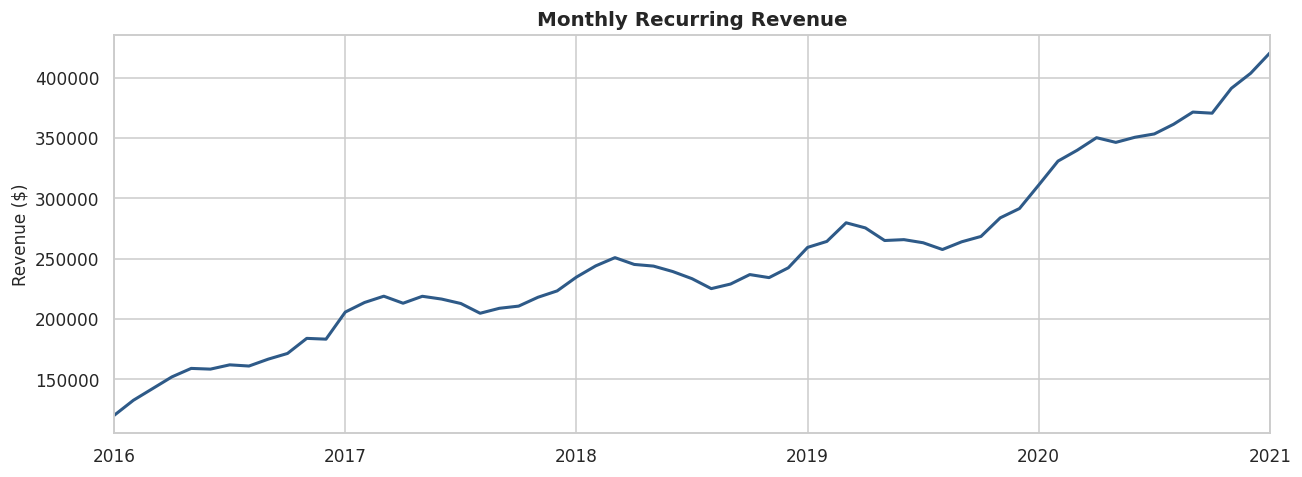

In [3]:
mrr.to_frame().to_csv(SERIES_OUT)
fig, ax = plt.subplots(figsize=(12, 4.5))
mrr.plot(ax=ax, color="#2E5A88", lw=2)
ax.set_title("Monthly Recurring Revenue"); ax.set_ylabel("Revenue ($)")
plt.tight_layout(); save_fig(fig, "02_mrr_series"); plt.show()

## 2. Seasonal decomposition

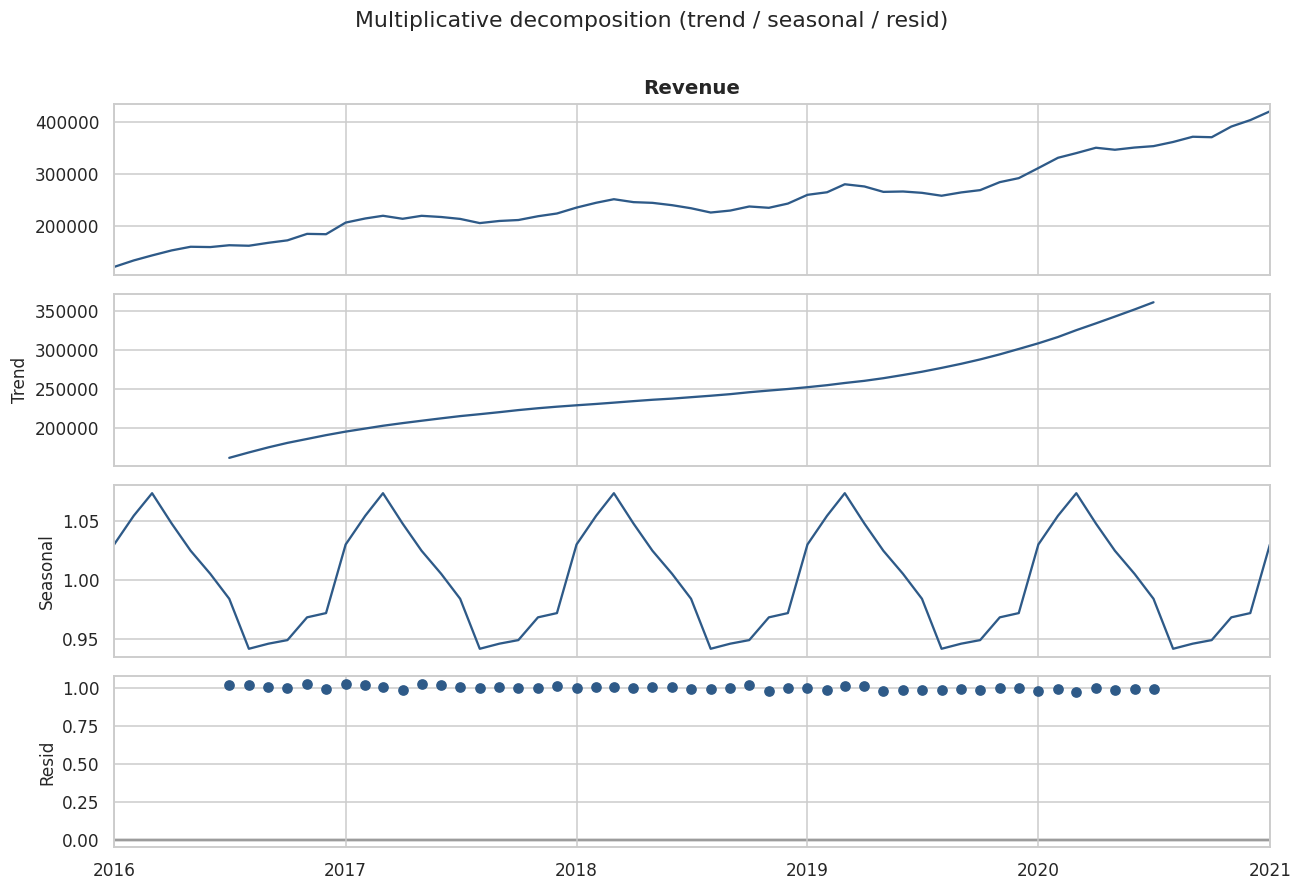

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(mrr, model="multiplicative", period=12)
fig = decomp.plot(); fig.set_size_inches(12, 8)
fig.suptitle("Multiplicative decomposition (trend / seasonal / resid)", y=1.01)
plt.tight_layout(); save_fig(fig, "02_decomposition"); plt.show()

## 3. Train / test split
The last **12 months** are held out to score each model out-of-sample.

In [5]:
H = 12
train, test = mrr.iloc[:-H], mrr.iloc[-H:]
print(f"Train: {len(train)} months  |  Test: {len(test)} months")
results, forecasts = [], {}

Train: 49 months  |  Test: 12 months


### 3a. SARIMA

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.get_forecast(H)
forecasts["SARIMA"] = sarima_fc.predicted_mean.values
results.append(forecast_scores(test.values, forecasts["SARIMA"], "SARIMA"))
print(results[-1])

{'Model': 'SARIMA', 'MAE': 43832.34, 'RMSE': 48134.21, 'MAPE (%)': 11.7}


### 3b. Holt-Winters (triple exponential smoothing)

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw = ExponentialSmoothing(train, trend="add", seasonal="add",
                          seasonal_periods=12).fit()
forecasts["Holt-Winters"] = hw.forecast(H).values
results.append(forecast_scores(test.values, forecasts["Holt-Winters"], "Holt-Winters"))
print(results[-1])

{'Model': 'Holt-Winters', 'MAE': 33060.1, 'RMSE': 38663.24, 'MAPE (%)': 8.72}

### 3c. Prophet

In [8]:
if HAS_PROPHET:
    pdf = train.reset_index(); pdf.columns = ["ds", "y"]
    pm = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, interval_width=0.90)
    pm.fit(pdf)
    future = pm.make_future_dataframe(periods=H, freq="MS")
    pfc = pm.predict(future).set_index("ds")
    forecasts["Prophet"] = pfc["yhat"].iloc[-H:].values
    results.append(forecast_scores(test.values, forecasts["Prophet"], "Prophet"))
    print(results[-1])
else:
    print("Skipped Prophet (not installed).")

01:53:57 - cmdstanpy - INFO - Chain [1] start processing


01:53:57 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet', 'MAE': 41689.33, 'RMSE': 44532.32, 'MAPE (%)': 11.18}


## 4. Model comparison (hold-out)

In [9]:
comparison = scores_table(results)
best_model = comparison.iloc[0]["Model"]
print(f"Best model by RMSE: {best_model}")
comparison

Best model by RMSE: Holt-Winters


,Model,MAE,RMSE,MAPE (%)
0,Holt-Winters,33060.10,38663.24,8.72
1,Prophet,41689.33,44532.32,11.18
2,SARIMA,43832.34,48134.21,11.70


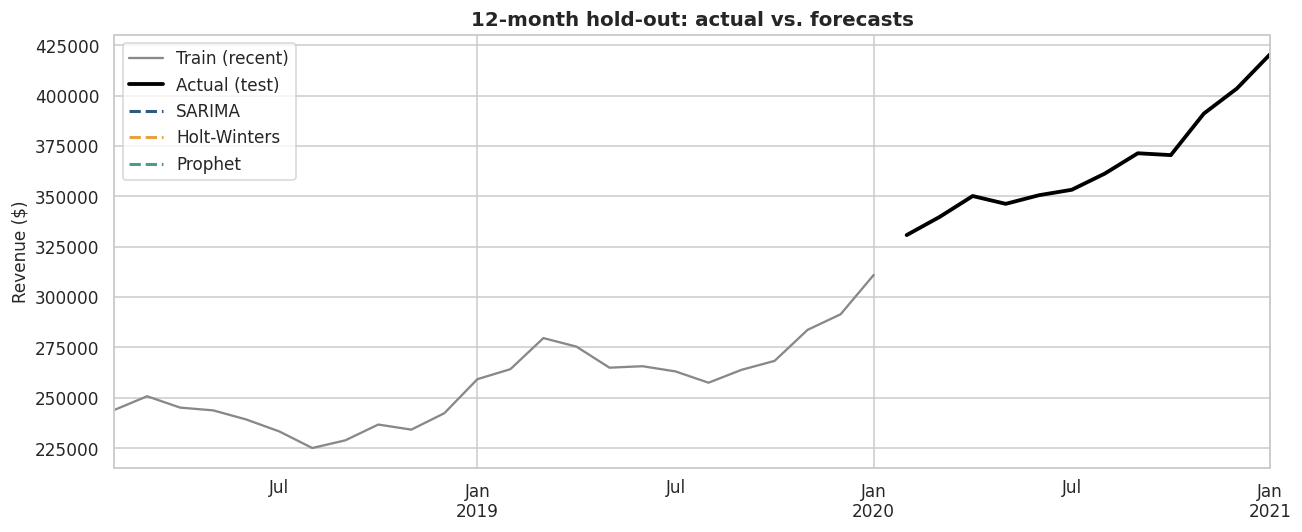

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
train.iloc[-24:].plot(ax=ax, label="Train (recent)", color="#888")
test.plot(ax=ax, label="Actual (test)", color="black", lw=2.5)
colors = {"SARIMA": "#2E5A88", "Holt-Winters": "#E6A23C", "Prophet": "#4C9A8E"}
for name, fc in forecasts.items():
    ax.plot(test.index, fc, "--", label=name, color=colors.get(name), lw=2)
ax.set_title("12-month hold-out: actual vs. forecasts"); ax.legend()
ax.set_ylabel("Revenue ($)")
plt.tight_layout(); save_fig(fig, "02_holdout_forecasts"); plt.show()

## 5. 12-month forward forecast
The best model is **refit on the full series** and projected 12 months beyond the last
observation, with a confidence band for the dashboard.

In [11]:
future_idx = pd.date_range(mrr.index.max() + pd.DateOffset(months=1), periods=H, freq="MS")

if best_model == "SARIMA":
    final = SARIMAX(mrr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = final.get_forecast(H); mean = fc.predicted_mean.values
    ci = fc.conf_int(alpha=0.10).values; lower, upper = ci[:, 0], ci[:, 1]
elif best_model == "Holt-Winters":
    final = ExponentialSmoothing(mrr, trend="add", seasonal="add",
                                 seasonal_periods=12).fit()
    mean = final.forecast(H).values
    resid_std = (mrr - final.fittedvalues).std()
    lower, upper = mean - 1.64*resid_std, mean + 1.64*resid_std
else:  # Prophet
    pdf = mrr.reset_index(); pdf.columns = ["ds", "y"]
    final = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, interval_width=0.90).fit(pdf)
    fut = final.make_future_dataframe(periods=H, freq="MS")
    pr = final.predict(fut).set_index("ds").iloc[-H:]
    mean, lower, upper = pr["yhat"].values, pr["yhat_lower"].values, pr["yhat_upper"].values

forecast_df = pd.DataFrame({"Month": future_idx, "Forecast": mean.round(2),
                            "Lower": lower.round(2), "Upper": upper.round(2)})
forecast_df.to_csv(FORECAST_OUT, index=False)
forecast_df

,Month,Forecast,Lower,Upper
0,2021-02-01,441488.26,429290.91,453685.61
1,2021-03-01,453963.81,441766.46,466161.16
2,2021-04-01,458500.37,446303.02,470697.72
3,2021-05-01,461353.84,449156.49,473551.20
4,2021-06-01,464756.64,452559.28,476953.99
5,2021-07-01,466550.29,454352.94,478747.64
6,2021-08-01,468228.44,456031.09,480425.79
7,2021-09-01,478158.96,465961.61,490356.31
8,2021-10-01,484407.40,472210.05,496604.75
9,2021-11-01,499870.59,487673.24,512067.94


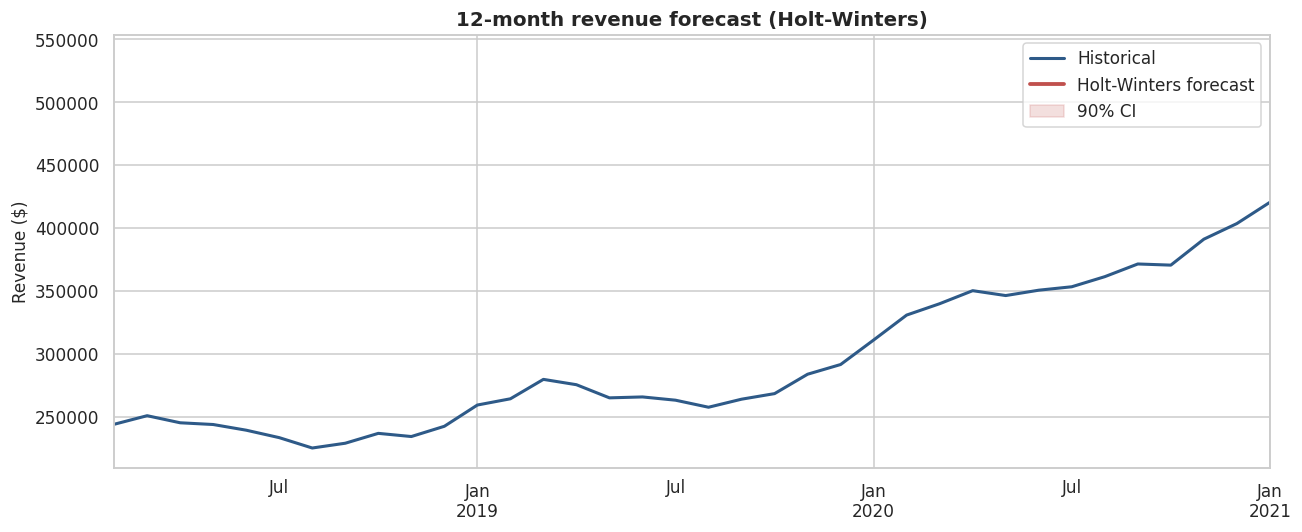

Projected next-12-month revenue: $5,713,047
Avg monthly forecast: $476,087 (vs last 12m actual $365,722)


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
mrr.iloc[-36:].plot(ax=ax, label="Historical", color="#2E5A88", lw=2)
ax.plot(future_idx, mean, color="#C0504D", lw=2.5, label=f"{best_model} forecast")
ax.fill_between(future_idx, lower, upper, color="#C0504D", alpha=0.18, label="90% CI")
ax.axvline(mrr.index.max(), color="grey", ls=":")
ax.set_title(f"12-month revenue forecast ({best_model})"); ax.legend()
ax.set_ylabel("Revenue ($)")
plt.tight_layout(); save_fig(fig, "02_forecast_12m"); plt.show()

print(f"Projected next-12-month revenue: ${mean.sum():,.0f}")
print(f"Avg monthly forecast: ${mean.mean():,.0f} "
      f"(vs last 12m actual ${mrr.iloc[-12:].mean():,.0f})")

## Key takeaways
- The MRR series shows a clear **upward trend** with a **12-month seasonal cycle**
  (summer peak, December dip).
- All three models track the hold-out well; the comparison table selects the lowest-
  error model on RMSE for the production forecast.
- The forward forecast and its confidence band are saved to
  `data/processed/revenue_forecast.csv` and surfaced on the executive dashboard.
